In [1]:
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.linear_model import LinearRegression

from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor

import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv(
r"C:\Users\Nithin\OneDrive\Desktop\Projects\Spatial–Temporal Uber Fare Prediction Engine\Data\Cleaned data\cleaned_uber_data.csv"
)

df.head()

,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,Year,Month,Day,Hour,Minute,Weekday,Peak_Hour,Distance_km,Distance_Category,Fare_Category
0,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06+00:00,-73.999817,40.738354,-73.999512,40.723217,1,2015,5,7,19,52,Thursday,Peak,1.683323,Very Short,Low
1,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56+00:00,-73.994355,40.728225,-73.994710,40.750325,1,2009,7,17,20,4,Friday,Peak,2.457590,Short,Low
2,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00+00:00,-74.005043,40.740770,-73.962565,40.772647,1,2009,8,24,21,45,Monday,Non Peak,5.036377,Medium,Medium
3,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21+00:00,-73.976124,40.790844,-73.965316,40.803349,3,2009,6,26,8,22,Friday,Peak,1.661683,Very Short,Low
4,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00+00:00,-73.925023,40.744085,-73.973082,40.761247,5,2014,8,28,17,47,Thursday,Peak,4.475450,Short,Medium


In [5]:
encoder = LabelEncoder()

df["Weekday"] = encoder.fit_transform(df["Weekday"])

df["Peak_Hour"] = encoder.fit_transform(df["Peak_Hour"])

df["Distance_Category"] = encoder.fit_transform(df["Distance_Category"])

df["Fare_Category"] = encoder.fit_transform(df["Fare_Category"])

In [7]:
features = [
    "Distance_km",
    "Hour",
    "Weekday",
    "Month",
    "passenger_count",
    "Peak_Hour"
]

X = df[features]

y = df["fare_amount"]

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [11]:
lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [13]:
print("Linear Regression")

print("MAE :", mean_absolute_error(y_test, lr_pred))

print("RMSE :", np.sqrt(mean_squared_error(y_test, lr_pred)))

print("R2 :", r2_score(y_test, lr_pred))

Linear Regression
MAE : 3.3021403144451877
RMSE : 4.15929737968244
R2 : 0.002028991698567517


In [15]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [17]:
print("Random Forest")

print("MAE :", mean_absolute_error(y_test, rf_pred))

print("RMSE :", np.sqrt(mean_squared_error(y_test, rf_pred)))

print("R2 :", r2_score(y_test, rf_pred))

Random Forest
MAE : 1.721643074990947
RMSE : 2.3908486366239923
R2 : 0.6702520198067957


In [19]:
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

In [21]:
print("XGBoost")

print("MAE :", mean_absolute_error(y_test, xgb_pred))

print("RMSE :", np.sqrt(mean_squared_error(y_test, xgb_pred)))

print("R2 :", r2_score(y_test, xgb_pred))

XGBoost
MAE : 1.6060779083067824
RMSE : 2.2651634817695885
R2 : 0.7040099698802825


In [23]:
results = pd.DataFrame({

"Model":[
"Linear Regression",
"Random Forest",
"XGBoost"
],

"MAE":[
mean_absolute_error(y_test,lr_pred),
mean_absolute_error(y_test,rf_pred),
mean_absolute_error(y_test,xgb_pred)
],

"RMSE":[
np.sqrt(mean_squared_error(y_test,lr_pred)),
np.sqrt(mean_squared_error(y_test,rf_pred)),
np.sqrt(mean_squared_error(y_test,xgb_pred))
],

"R2":[
r2_score(y_test,lr_pred),
r2_score(y_test,rf_pred),
r2_score(y_test,xgb_pred)
]

})

results

,Model,MAE,RMSE,R2
0,Linear Regression,3.302140,4.159297,0.002029
1,Random Forest,1.721643,2.390849,0.670252
2,XGBoost,1.606078,2.265163,0.704010


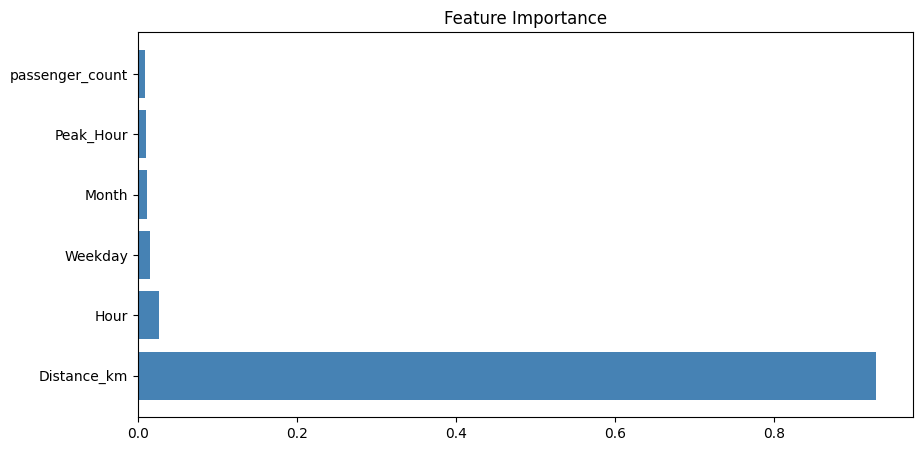

In [25]:
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    "Feature": features,
    "Importance": xgb.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,5))

plt.barh(
importance["Feature"],
importance["Importance"],
color="steelblue"
)

plt.title("Feature Importance")

plt.show()

In [27]:
import os

os.makedirs(
r"C:\Users\Nithin\OneDrive\Desktop\Projects\Spatial–Temporal Uber Fare Prediction Engine\Models",
exist_ok=True
)

In [29]:
joblib.dump(
xgb,
r"C:\Users\Nithin\OneDrive\Desktop\Projects\Spatial–Temporal Uber Fare Prediction Engine\Models\xgb_model.pkl"
)

print("✅ Model Saved Successfully")

✅ Model Saved Successfully


In [31]:
df["Predicted_Fare"] = xgb.predict(X)

df["Prediction_Error"] = (
df["fare_amount"] -
df["Predicted_Fare"]
)

In [33]:
df.to_csv(
r"C:\Users\Nithin\OneDrive\Desktop\Projects\Spatial–Temporal Uber Fare Prediction Engine\Data\Cleaned data\prediction_output.csv",
index=False
)

print("✅ Prediction dataset saved.")

✅ Prediction dataset saved.
